# Aufgabe 4

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
import skimage.transform as t

## 4.1

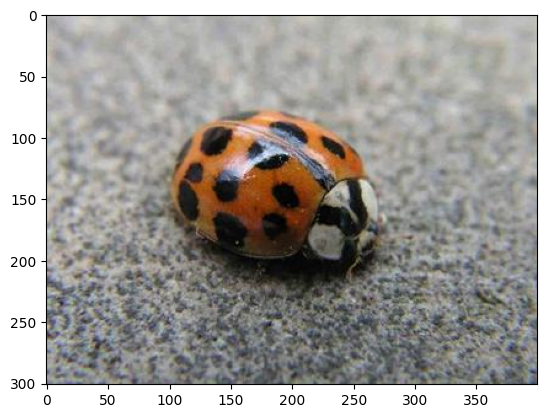

In [2]:
original = imread("ladybug.jpg")
plt.imshow(original)

In [3]:
def rgb_to_irgby(img):
    """Konvertiert ein RGB-Bild in den I-RG-BY Farbraum."""

    # Konvertiere zu float32 um negative Werte und Genauigkeit zu unterstützen
    img_float = img.astype(np.float32)
    
    # Extrahiere RGB-Kanäle
    R = img_float[:, :, 0]
    G = img_float[:, :, 1]
    B = img_float[:, :, 2]
    
    # Berechne I-RG-BY Kanäle
    I = (R + G + B) / 3
    RG = R - G
    BY = B - (R + G) / 2
    
    result = np.stack([I, RG, BY], axis=-1)
    
    return result

In [4]:
def compute_saliency_map(img_irgby):
    """
    Berechnet eine Salienz-Karte für ein Bild im I-RG-BY Farbraum.
    
    Für jeden Pixel wird der Kontrast zwischen einer 11×11 Zentrumsregion 
    und einer 21×21 Umgebungsregion berechnet. Dies wird für alle drei Kanäle
    durchgeführt und die Ergebnisse werden addiert.
    
    Parameters:
    -----------
    img_irgby : ndarray
        Ein Bild im I-RG-BY Farbraum mit Form (height, width, 3)
    
    Returns:
    --------
    saliency_map : ndarray
        Die berechnete Salienz-Karte mit Werten zwischen 0 und 1
    """
    height, width, channels = img_irgby.shape
    saliency_map = np.zeros((height, width), dtype=np.float32)
    
    # Zentrumsregion: 11×11, Umgebungsregion: 21×21
    center_size = 11
    surround_size = 21
    center_half = center_size // 2      # 5
    surround_half = surround_size // 2  # 10
    
    # Für jeden Kanal
    for c in range(channels):
        channel = img_irgby[:, :, c]
        
        # Für jeden Pixel
        for y in range(height):
            for x in range(width):
                # Zentrumsregion Grenzen (mit Bildrand-Anpassung)
                center_y_min = max(0, y - center_half)
                center_y_max = min(height, y + center_half + 1)
                center_x_min = max(0, x - center_half)
                center_x_max = min(width, x + center_half + 1)
                
                # Umgebungsregion Grenzen (mit Bildrand-Anpassung)
                surround_y_min = max(0, y - surround_half)
                surround_y_max = min(height, y + surround_half + 1)
                surround_x_min = max(0, x - surround_half)
                surround_x_max = min(width, x + surround_half + 1)
                
                # Mittlere Werte berechnen
                center_mean = np.mean(channel[center_y_min:center_y_max, center_x_min:center_x_max])
                surround_mean = np.mean(channel[surround_y_min:surround_y_max, surround_x_min:surround_x_max])
                
                # Kontrast als absolute Differenz berechnen
                contrast = np.abs(center_mean - surround_mean)
                saliency_map[y, x] += contrast
    
    # Salienz-Karte auf [0, 1] skalieren
    saliency_min = np.min(saliency_map)
    saliency_max = np.max(saliency_map)
    
    if saliency_max > saliency_min:
        saliency_map = (saliency_map - saliency_min) / (saliency_max - saliency_min)
    
    return saliency_map

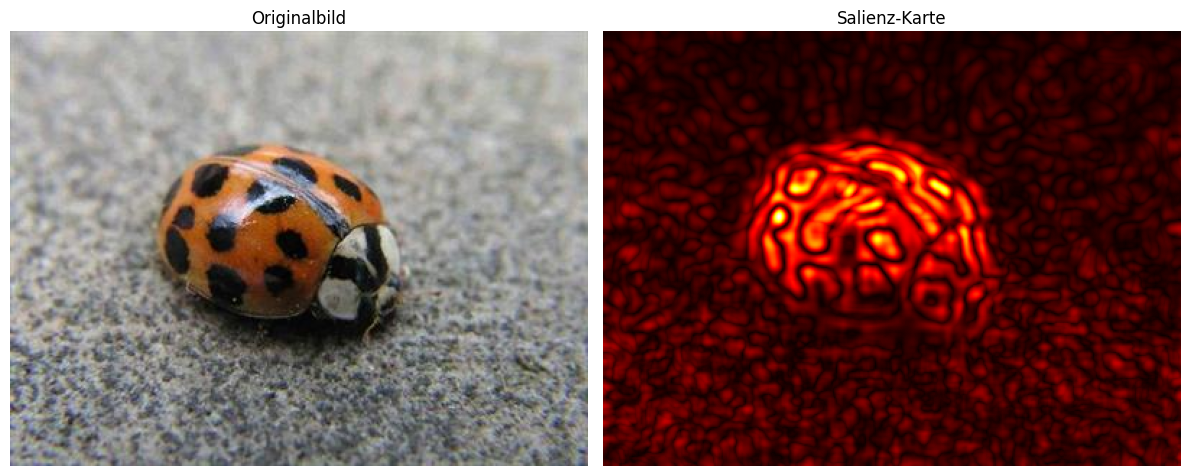

Salienz-Karte Wertebereich: [0.0000, 1.0000]


In [5]:
# Konvertiere das Originalbild zu I-RG-BY Farbraum
img_irgby = rgb_to_irgby(original)

# Berechne die Salienz-Karte
saliency_map = compute_saliency_map(img_irgby)

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original)
axes[0].set_title('Originalbild')
axes[0].axis('off')

axes[1].imshow(saliency_map, cmap='hot')
axes[1].set_title('Salienz-Karte')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Salienz-Karte Wertebereich: [{saliency_map.min():.4f}, {saliency_map.max():.4f}]")